<a href="https://colab.research.google.com/github/Tiago150196/analise-vendas-negocio/blob/main/C%C3%B3pia_de_Untitled2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Análise de Dados para Otimização de Campanhas de Marketing em Varejo




🎯 OBJETIVO

Analisar dados de clientes de um supermercado para identificar quais possuem maior probabilidade de aderir a uma assinatura com desconto de 20%.

❓ PERGUNTAS DE NEGÓCIO
- Quais clientes gastam mais?
- Qual perfil de cliente compra com mais frequência?
- Clientes com filhos gastam mais ou menos?
- Existe relação entre renda e consumo?
- Quais clientes têm maior potencial para aderir à assinatura?

💡 INSIGHTS

- Clientes com maior renda apresentam maior gasto total.
- Clientes sem filhos tendem a consumir mais produtos premium.
- Clientes com alto gasto recorrente são os mais indicados para a assinatura.
- A campanha deve focar em clientes com alto consumo e baixa recência.

## 📥 Importação dos dados

Os dados foram carregados a partir de um arquivo CSV hospedado no GitHub.

Em alguns casos, arquivos CSV podem utilizar diferentes separadores, como vírgula (,) ou ponto e vírgula (;). Neste projeto, utilizamos o separador adequado para garantir a correta leitura dos dados.

In [ ]:
import pandas as pd

In [ ]:
url = 'https://raw.githubusercontent.com/alura-cursos/pandas/refs/heads/main/superstore_data.csv'

In [ ]:
dados_mercado = pd.read_csv(url)

In [ ]:
dados_mercado['Total_Gasto'] = (
    dados_mercado['MntWines'] +
    dados_mercado['MntFruits'] +
    dados_mercado['MntMeatProducts'] +
    dados_mercado['MntFishProducts'] +
    dados_mercado['MntSweetProducts']
)

dados_mercado['Idade'] = 2026 - dados_mercado['Year_Birth']

Variável filhos

In [ ]:
dados_mercado['Tem_Filho'] = dados_mercado['Kidhome'] + dados_mercado['Teenhome']

Quem gasta mais

In [ ]:
dados_mercado.groupby('Education')['Total_Gasto'].mean().sort_values(ascending=False)

,Total_Gasto
Education,
PhD,640.098765
Master,571.383784
Graduation,569.049689
2n Cycle,450.128079
Basic,58.962963


Renda vs gasto

In [ ]:
dados_mercado[['Income', 'Total_Gasto']].corr()

,Income,Total_Gasto
Income,1.000000,0.668062
Total_Gasto,0.668062,1.000000


Filhos vs gasto

In [ ]:
dados_mercado.groupby('Tem_Filho')['Total_Gasto'].mean()

,Total_Gasto
Tem_Filho,
0,1041.880878
1,431.958333
2,220.527316
3,256.000000


A baixa correlação entre recência e gasto indica que clientes que compraram recentemente não necessariamente são os que mais gastam, sugerindo que a frequência e o valor histórico são variáveis mais relevantes para segmentação.

In [ ]:
dados_mercado[['Recency', 'Total_Gasto']].corr()

,Recency,Total_Gasto
Recency,1.000000,0.019831
Total_Gasto,0.019831,1.000000


Observa-se uma tendência positiva entre renda e gasto total, indicando que clientes com maior renda tendem a apresentar maior volume de consumo.
No entanto, também existem variações, o que sugere que outros fatores além da renda podem influenciar o comportamento de compra.

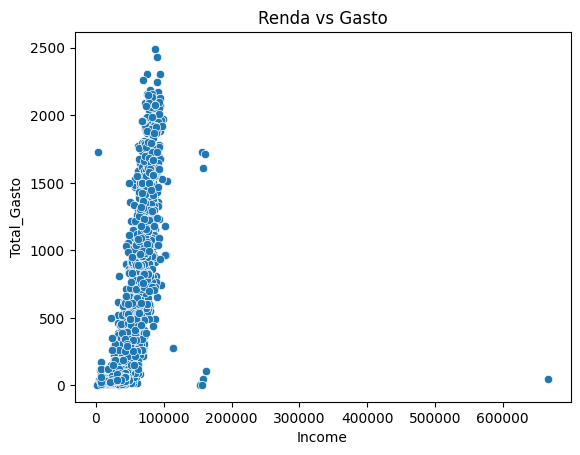

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x='Income', y='Total_Gasto', data=dados_mercado)
plt.title('Renda vs Gasto')
plt.show()

Análise da relação entre renda e gasto dos clientes

Para entender o comportamento de consumo dos clientes, foi analisada a relação entre a renda anual (Income) e o gasto total (Total_Gasto).
Essa análise permite identificar se clientes com maior poder aquisitivo tendem a consumir mais, o que pode orientar estratégias de segmentação e campanhas de marketing mais eficazes.

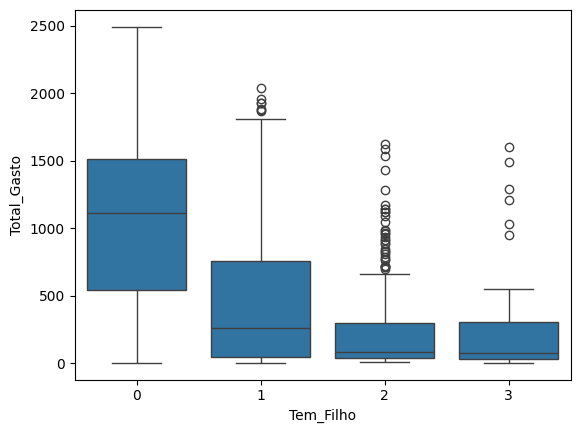

In [ ]:
sns.boxplot(x='Tem_Filho', y='Total_Gasto', data=dados_mercado)
plt.show()

Análise da tendência entre renda e gasto dos clientes

Com o objetivo de aprofundar a análise da relação entre renda e consumo, foi adicionada uma linha de tendência ao gráfico de dispersão entre Income e Total_Gasto.
Essa abordagem permite identificar de forma mais clara a direção da relação entre as variáveis, evidenciando se o aumento da renda está associado a um crescimento no gasto dos clientes.

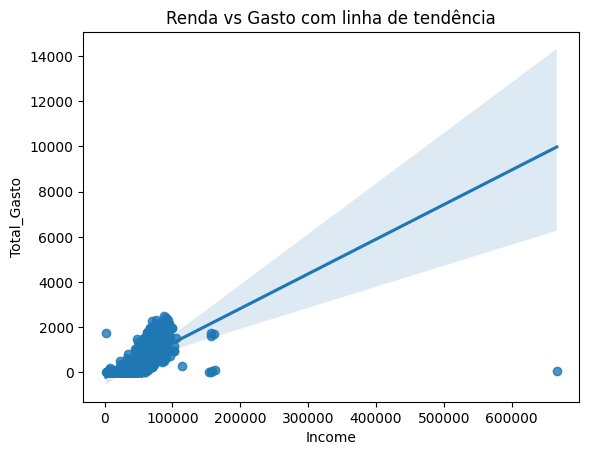

In [68]:
sns.regplot(x='Income', y='Total_Gasto', data=dados_mercado)
plt.title('Renda vs Gasto com linha de tendência')
plt.show()

A linha de tendência confirma a existência de uma relação positiva entre renda e gasto, indicando que, em média, clientes com maior renda tendem a consumir mais.
Apesar disso, a dispersão dos pontos mostra que a renda não é o único fator determinante do consumo, sugerindo a influência de outras variáveis no comportamento dos clientes.

A distribuição do gasto total permite identificar a concentração de clientes em diferentes faixas de consumo, evidenciando possíveis grupos de baixo e alto valor.

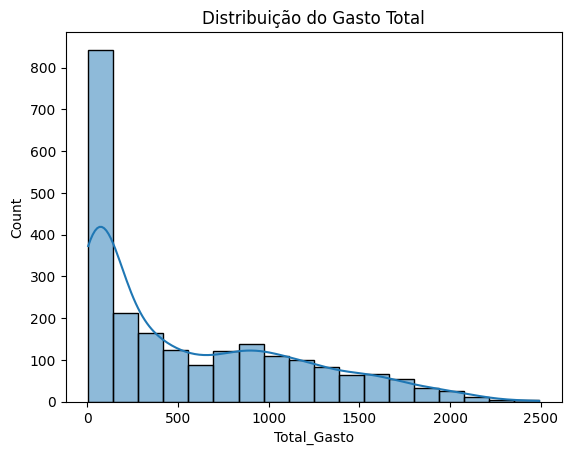

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(dados_mercado['Total_Gasto'], kde=True)
plt.title('Distribuição do Gasto Total')
plt.show()

A identificação dos clientes com maior gasto permite direcionar estratégias de retenção e fidelização, focando nos consumidores de maior valor para o negócio.

In [71]:
dados_mercado.sort_values(by='Total_Gasto', ascending=False).head(10)

,Id,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain,Total_Gasto,Idade,Tem_Filho,Segmento
1404,1763,1988,Graduation,Together,87679.0,0,0,7/27/2013,62,1259,...,7,11,10,4,1,0,2491,38,0,Premium
672,5350,1991,Master,Single,90638.0,0,0,2/13/2014,29,1156,...,3,4,10,1,1,0,2429,35,0,Premium
671,5735,1991,Master,Single,90638.0,0,0,2/13/2014,29,1156,...,3,4,10,1,0,0,2429,35,0,Premium
1026,4580,1969,Graduation,Married,75759.0,0,0,10/25/2013,46,1394,...,9,7,9,5,1,0,2304,57,0,Premium
376,10133,1970,Graduation,Single,93790.0,0,0,12/2/2014,16,1302,...,6,7,12,2,1,0,2304,56,0,Premium
1864,4475,1949,PhD,Married,69098.0,0,0,2/16/2013,82,1315,...,7,8,9,5,0,0,2262,77,0,Premium
607,5453,1956,Master,Married,90226.0,0,0,9/26/2012,26,1083,...,4,7,12,2,0,0,2244,70,0,Premium
1293,737,1949,PhD,Married,80360.0,0,0,3/3/2013,56,1493,...,4,4,5,2,0,0,2188,77,0,Premium
1054,6248,1947,Master,Single,91712.0,0,0,10/17/2013,47,1276,...,9,7,11,3,1,0,2169,79,0,Premium
927,7503,1976,Graduation,Single,75825.0,0,0,12/10/2012,40,1032,...,5,8,9,4,1,0,2158,50,0,Premium


A análise estatística indica a presença de valores extremos (outliers), especialmente na variável renda. Esses pontos podem influenciar a análise e devem ser considerados na interpretação dos resultados.

In [72]:
dados_mercado[['Income', 'Total_Gasto']].describe()

,Income,Total_Gasto
count,2216.000000,2240.000000
mean,52247.251354,561.776339
std,25173.076661,576.613680
min,1730.000000,4.000000
25%,35303.000000,55.000000
50%,51381.500000,341.000000
75%,68522.000000,964.000000
max,666666.000000,2491.000000


Para compreender a distribuição da renda dos clientes, foi utilizado um gráfico do tipo boxplot, que permite visualizar a concentração dos dados, a mediana e possíveis valores extremos (outliers).
Essa análise é importante para identificar a presença de clientes com rendas significativamente acima ou abaixo da média, o que pode impactar diretamente as estratégias de segmentação.

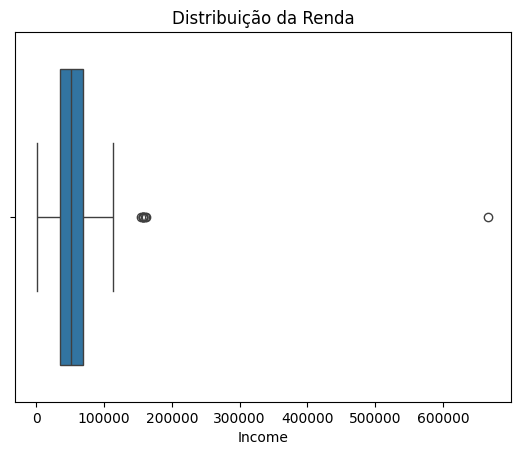

In [73]:
sns.boxplot(x=dados_mercado['Income'])
plt.title('Distribuição da Renda')
plt.show()

A segmentação por faixa etária permite identificar diferenças no comportamento de consumo entre grupos de idade, auxiliando na personalização de campanhas.

In [77]:
dados_mercado.groupby(
    pd.cut(dados_mercado['Idade'], bins=[18,30,45,60,100]),
    observed=False
)['Total_Gasto'].mean()

,Total_Gasto
Idade,
"(18, 30]",40.000000
"(30, 45]",537.840731
"(45, 60]",494.144724
"(60, 100]",652.208868


Observa-se a presença de valores extremos (outliers) na variável renda, indicando que alguns clientes possuem rendas significativamente superiores à maioria.
A maior concentração de clientes está em faixas intermediárias de renda, sugerindo que o público predominante possui perfil econômico moderado.
Esses outliers devem ser considerados com cautela, pois podem influenciar análises estatísticas e decisões de negócio.

A segmentação dos clientes evidencia a predominância de consumidores de baixo valor, com uma parcela menor de clientes de alto valor e premium.
Essa distribuição reforça a importância de estratégias focadas na retenção dos clientes mais valiosos, que representam maior retorno para o negócio.

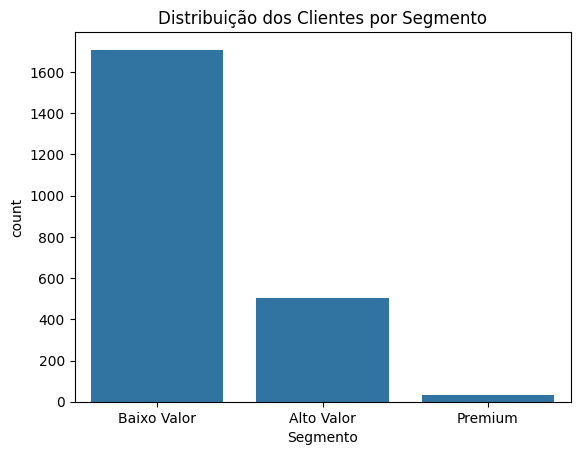

In [75]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Segmento', data=dados_mercado)
plt.title('Distribuição dos Clientes por Segmento')
plt.show()

A análise dos dados permitiu identificar padrões relevantes no comportamento dos clientes.
Observou-se que clientes com maior renda tendem a apresentar maior gasto, indicando uma relação positiva entre poder aquisitivo e consumo.
Além disso, clientes sem filhos demonstram maior gasto médio, especialmente em produtos premium, o que pode indicar maior disponibilidade financeira.
A variável de recência mostrou baixa correlação com o gasto, sugerindo que o tempo desde a última compra, isoladamente, não é suficiente para prever o consumo.
Com base nesses achados, recomenda-se que campanhas de marketing sejam direcionadas para clientes com alto gasto histórico e maior renda, priorizando estratégias de retenção e fidelização.

Para apoiar estratégias de marketing, os clientes foram segmentados com base no valor total gasto, permitindo identificar grupos com maior potencial de retorno. Além disso, a segmentação dos clientes permite priorizar ações estratégicas, direcionando esforços para grupos com maior potencial de retorno e otimizando investimentos em marketing.

In [69]:
dados_mercado['Segmento'] = 'Baixo Valor'

dados_mercado.loc[dados_mercado['Total_Gasto'] > 1000, 'Segmento'] = 'Alto Valor'
dados_mercado.loc[dados_mercado['Total_Gasto'] > 2000, 'Segmento'] = 'Premium'

dados_mercado['Segmento'].value_counts()

,count
Segmento,
Baixo Valor,1708
Alto Valor,501
Premium,31
